# Phase 01. Real supervised fine-tuning on a real specialization task.

I read the LLM-JEPA paper. The headline result, that an auxiliary representation-prediction loss improves supervised fine-tuning, was clean and the controls were sharp. The experiments were at parameter counts most engineers do not have access to.

> Does the same mechanism survive at 0.5B parameters, on consumer hardware, in a way that would matter for real-world small-model deployment?

Concretely: I want a specialized 0.5B model with a specific PostgreSQL schema baked into its weights so a natural-language question produces valid SQL against that schema without any schema hint at inference. Zero context tokens spent describing tables. Just NL in, SQL out. That is the deployment story small models can actually own.

This notebook is Phase 01. Plain supervised fine-tuning, no JEPA yet. The commercial insurance dataset is 14,000 templated NL-to-SQL pairs (see `data/nl_sql.jsonl` and the schema reference at `data/commercial_insurance_schema.md`).

**Winning config (Run 6):** 12 disjoint 1,000-example epochs, LR peak 2.5e-6 with cosine decay to 20% of peak, batch 2 × grad_accum 8. Loss plateaued at 0.07. Wall-clock ~70 min on an RTX 4060 laptop GPU.

**The headline read.** Strict exact-match is 0/100 on the held-out eval. That number is misleading — the metric is too rigid for templated PostgreSQL with alias flexibility. The diagnostic cell at the bottom reveals what strict EM misses:

- **96/100** predictions reference the correct schema tables (base was 0)
- **74%** mean token overlap between prediction and target
- **36/100** predictions match with >90% token overlap (near-verbatim)
- **92/100** use `p.` alias for policies, **94/100** use `a.` for accounts (target conventions)
- **0/100** truncated or stuck in repetition loops

The model learned the schema, the aliasing conventions, and PostgreSQL idioms. It just doesn't produce byte-identical output. That is legitimate template-family generalization from 12,000 unique training examples with zero repetition.

**What Phase 03 (JEPA) has to beat.** This baseline. Real learning happened, real gaps remain (precise column selection, join-count matching — only 15/100 match target's join count). Those are "representation of the target isn't quite there yet" problems, which is what an auxiliary representation-prediction loss is supposed to help with. If JEPA can move any of those diagnostic metrics meaningfully upward, the mechanism scales down to 0.5B on consumer hardware.


## What this notebook does not do

No JEPA loss. No LoRA. No quantization. Those are Phases 03, 04, 05.

The reason for the slow buildup is interpretability. Add several moving parts at once and the eval delta becomes hard to attribute. By Phase 03 there will be a trusted SFT baseline, a clean representation extractor, and only then can an auxiliary loss be compared honestly against the baseline.


In [47]:
import json
import math
import os
import random
import re
import sys
import time
from pathlib import Path

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Walk up to the repo root so paths resolve regardless of where Jupyter
# was launched. pyproject.toml lives one level above notebooks/.
HERE = Path.cwd()
REPO = HERE
while not (REPO / "pyproject.toml").exists() and REPO != REPO.parent:
    REPO = REPO.parent
NOTEBOOK_DIR = REPO / "notebooks"
os.chdir(NOTEBOOK_DIR)

DATA_PATH = NOTEBOOK_DIR / "data" / "nl_sql.jsonl"
LOCAL_MODEL_DIR = NOTEBOOK_DIR / "model" / "Qwen2.5-0.5B-Instruct"
print("notebook dir:", NOTEBOOK_DIR)
print("data file   :", DATA_PATH, "exists:", DATA_PATH.exists())
print("base model  :", LOCAL_MODEL_DIR, "exists:", LOCAL_MODEL_DIR.exists())

OUTPUT_DIR = NOTEBOOK_DIR / "01-outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print("outputs     :", OUTPUT_DIR)


notebook dir: c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks
data file   : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\data\nl_sql.jsonl exists: True
base model  : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct exists: True
outputs     : c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\01-outputs


## The base model

`Qwen/Qwen2.5-0.5B-Instruct`. 494M parameters, instruction-tuned. The cell below downloads it into `./model/Qwen2.5-0.5B-Instruct/` on first run, so the artifact lives visibly next to the notebook.


In [48]:
# Pull Qwen2.5-0.5B-Instruct into ./model/Qwen2.5-0.5B-Instruct/ on first run.
# ~1GB. Subsequent runs are no-ops.
from huggingface_hub import snapshot_download

if not (LOCAL_MODEL_DIR / "config.json").exists():
    print(f"Downloading Qwen/Qwen2.5-0.5B-Instruct -> {LOCAL_MODEL_DIR}")
    LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    snapshot_download(repo_id="Qwen/Qwen2.5-0.5B-Instruct", local_dir=str(LOCAL_MODEL_DIR))
    print("Downloaded.")
else:
    print(f"Base model already present at {LOCAL_MODEL_DIR}")

MODEL_NAME = str(LOCAL_MODEL_DIR)


Base model already present at c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\model\Qwen2.5-0.5B-Instruct


## Hyperparameter dashboard

Every knob is here. Change something, re-run every cell below. One knob at a time when sweeping — otherwise the read on what moved gets muddy.

Defaults are calibrated for a laptop-class CUDA device (RTX 4070-class). Expect wall-clock in the 10 to 20 minute range for training plus eval. If you drop to CPU, cut `MAX_TRAIN_EXAMPLES` to around 500 and expect 30 to 60 minutes.


In [104]:
# ─── Data ───
MAX_TRAIN_EXAMPLES = 1000     # examples resampled fresh from the train pool each epoch.
MAX_EVAL_EXAMPLES = 100      # held-out eval slice.
EVAL_FRACTION = 0.10         # eval share of the full 14k before pool sampling.
SEQ_LEN = 1024               # accommodates the CTE-heavy Scenario targets.

# ─── Model ───
DTYPE = "auto"               # "auto" | "float32" | "bfloat16" | "float16". CUDA gets bf16.
DEVICE = "auto"              # "auto" | "cpu" | "cuda".
FREEZE_FIRST_N_LAYERS = 0    # 0 = full FT. Qwen 0.5B has 24 transformer blocks.
GRADIENT_CHECKPOINTING = False

# ─── Training ───
NUM_EPOCHS = 12              # resample rounds. Each pulls a fresh random slice from the pool.
BATCH_SIZE = 1
GRAD_ACCUM_STEPS = 16
LEARNING_RATE = 2.5e-6         # lowered from 2e-5. Precious single-shot gradient signal.
WEIGHT_DECAY = 0.08          # bumped from 0.01. Actively pulls weights toward zero.
MAX_GRAD_NORM = 1.0
SEED = 1337

# ─── Scheduler ───
SCHEDULER = "cosine"
WARMUP_RATIO = 0.08
MIN_LR_RATIO = 0.2

# ─── Generation / eval ───
MAX_NEW_TOKENS = 512

# ─── Logging ───
LOG_EVERY = 5


## The data

14,000 hand-generated NL-to-PostgreSQL pairs over a 24-table commercial insurance schema. The schema reference lives at `data/commercial_insurance_schema.md`. Prompt and target ranges:

- prompt: 64 to 216 chars, mean 156.
- target: 230 to 1425 chars, mean 1082.

Prompt style is terse and analytical. "List active property policies effective in 2021 with account, carrier, premium, retention ratio, and risk score." No conversational fluff. Target style is PostgreSQL flavored: `date_trunc`, `nullif`, `coalesce`, CTEs, window functions.

**Templated** is the honest word for it. Whole tranches of the file are the same query shape with different line-of-business, state, or year parameters swapped in. That matters for the eval integrity note further down. Random train/eval split will occasionally put near-duplicates on opposite sides of the split.


In [106]:
SYSTEM_PROMPT = (
    "Translate the user's request into a single PostgreSQL statement. "
    "Reply with SQL only, ending in ';'."
)

def load_pairs(path):
    pairs = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        if "prompt" not in obj or "target" not in obj:
            raise ValueError(f"Bad row: {line!r}")
        pairs.append({"prompt": obj["prompt"], "target": obj["target"]})
    return pairs

def _chat_messages(prompt, target=None):
    msgs = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": prompt},
    ]
    if target is not None:
        msgs.append({"role": "assistant", "content": target})
    return msgs

def build_prompt_text(tokenizer, prompt):
    return tokenizer.apply_chat_template(
        _chat_messages(prompt, target=None),
        tokenize=False, add_generation_prompt=True,
    )

pairs = load_pairs(DATA_PATH)
print(f"{len(pairs)} pairs loaded\n")
for p in pairs[:2]:
    print("Q:", p["prompt"])
    print("A:", p["target"][:200] + ("..." if len(p["target"]) > 200 else ""))
    print()


14000 pairs loaded

Q: List active property policies effective in 2021 with account, carrier, premium, retention ratio, and risk score.
A: select p.policy_id, p.policy_number, a.account_name, ca.carrier_name, p.line_of_business, p.effective_date, p.expiration_date, p.written_premium, p.retention_ratio, p.risk_score from policies p join a...

Q: List active general liability policies effective in 2021 with account, carrier, premium, retention ratio, and risk score.
A: select p.policy_id, p.policy_number, a.account_name, ca.carrier_name, p.line_of_business, p.effective_date, p.expiration_date, p.written_premium, p.retention_ratio, p.risk_score from policies p join a...



## The masking contract

Load-bearing invariant of Phase 01. Every prompt token, every padding token, and the assistant role marker itself get label `-100`. Only the target SQL and its closing `<|im_end|>` carry gradient.

The mechanism is `-100` as PyTorch's `CrossEntropyLoss` `ignore_index`. If a prompt token leaks into the loss, the model can "learn" by re-emitting the prompt and any downstream JEPA result becomes uninterpretable.

The next cell renders one tokenized example, token by token. Everything before the assistant SQL should be `[    ]` (masked). Everything after should be `[loss]` up to `<|im_end|>`.


In [108]:
def tokenize_pair(tokenizer, pair, max_len):
    prefix_text = tokenizer.apply_chat_template(
        _chat_messages(pair["prompt"], target=None),
        tokenize=False, add_generation_prompt=True,
    )
    full_text = tokenizer.apply_chat_template(
        _chat_messages(pair["prompt"], pair["target"]),
        tokenize=False, add_generation_prompt=False,
    )
    prefix_ids = tokenizer(prefix_text, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"]
    if len(full_ids) > max_len:
        full_ids = full_ids[:max_len]
    prefix_len = min(len(prefix_ids), len(full_ids))

    input_ids = torch.tensor(full_ids, dtype=torch.long)
    attention_mask = torch.ones_like(input_ids)
    labels = input_ids.clone()
    labels[:prefix_len] = -100
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}

from torch.utils.data import Dataset, DataLoader

class SFTDataset(Dataset):
    def __init__(self, pairs, tokenizer, max_len):
        self.pairs = list(pairs)
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        return tokenize_pair(self.tokenizer, self.pairs[idx], self.max_len)

def collate_sft(batch, pad_token_id):
    max_len = max(item["input_ids"].shape[0] for item in batch)
    input_ids = torch.full((len(batch), max_len), pad_token_id, dtype=torch.long)
    attention_mask = torch.zeros((len(batch), max_len), dtype=torch.long)
    labels = torch.full((len(batch), max_len), -100, dtype=torch.long)
    for i, item in enumerate(batch):
        n = item["input_ids"].shape[0]
        input_ids[i, :n] = item["input_ids"]
        attention_mask[i, :n] = item["attention_mask"]
        labels[i, :n] = item["labels"]
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


In [109]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# Use a simpler example for the mask visualization. The Scenario CTEs
# produce 400+ token walls that overwhelm the terminal.
short_example = min(pairs, key=lambda p: len(p["target"]))
ex = tokenize_pair(tokenizer, short_example, max_len=SEQ_LEN)
n_loss = sum(1 for l in ex["labels"].tolist() if l != -100)
n_total = len(ex["input_ids"])
print(f"Example tokenizes to {n_total} tokens, {n_loss} carry gradient.\n")

# Only print the last 60 tokens plus a marker of what came before, to keep readable.
tail_start = max(0, n_total - 60)
if tail_start > 0:
    print(f"  ... ({tail_start} masked tokens above)\n")
for tok_id, label in list(zip(ex["input_ids"].tolist(), ex["labels"].tolist()))[tail_start:]:
    piece = tokenizer.decode([tok_id]).replace("\n", "\\n")
    marker = "loss" if label != -100 else "    "
    print(f"  [{marker}]  {piece!r}")


Example tokenizes to 121 tokens, 70 carry gradient.

  ... (61 masked tokens above)

  [loss]  ' as'
  [loss]  ' policy'
  [loss]  '_count'
  [loss]  ' from'
  [loss]  ' policies'
  [loss]  ' p'
  [loss]  ' where'
  [loss]  ' p'
  [loss]  '.e'
  [loss]  'ffective'
  [loss]  '_date'
  [loss]  ' >='
  [loss]  ' date'
  [loss]  " '"
  [loss]  '2'
  [loss]  '0'
  [loss]  '2'
  [loss]  '1'
  [loss]  '-'
  [loss]  '0'
  [loss]  '1'
  [loss]  '-'
  [loss]  '0'
  [loss]  '1'
  [loss]  "'"
  [loss]  ' and'
  [loss]  ' p'
  [loss]  '.e'
  [loss]  'ffective'
  [loss]  '_date'
  [loss]  ' <'
  [loss]  ' date'
  [loss]  " '"
  [loss]  '2'
  [loss]  '0'
  [loss]  '2'
  [loss]  '2'
  [loss]  '-'
  [loss]  '0'
  [loss]  '1'
  [loss]  '-'
  [loss]  '0'
  [loss]  '1'
  [loss]  "'"
  [loss]  ' group'
  [loss]  ' by'
  [loss]  ' p'
  [loss]  '.policy'
  [loss]  '_status'
  [loss]  ' order'
  [loss]  ' by'
  [loss]  ' policy'
  [loss]  '_count'
  [loss]  ' desc'
  [loss]  ' null'
  [loss]  's'
  [loss]  ' 

## Model. Loading and freezing.

Qwen2.5-0.5B-Instruct: 24 transformer blocks, an embedding table, an LM head. Roughly 494M parameters. `FREEZE_FIRST_N_LAYERS` is a trainable-depth knob. `0` is full fine-tune. `12` freezes the embedding plus the bottom 12 blocks, leaving upper blocks plus LM head trainable. Same underlying hypothesis as LoRA in Phase 04, just expressed with binary freezing.


In [110]:
def pick_dtype(name, device):
    # bf16 on CUDA where supported, fp32 on CPU (bf16 matmul on CPU is slow).
    if name == "auto":
        if device == "cuda" and torch.cuda.is_bf16_supported():
            return torch.bfloat16
        return torch.float32
    return {
        "float32": torch.float32, "fp32": torch.float32,
        "float16": torch.float16, "fp16": torch.float16,
        "bfloat16": torch.bfloat16, "bf16": torch.bfloat16,
    }[name]

def pick_device(name):
    if name == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    return name

device = pick_device(DEVICE)
dtype = pick_dtype(DTYPE, device)
print(f"device: {device}, dtype: {dtype}")

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=dtype)
model.to(device)

if GRADIENT_CHECKPOINTING:
    model.gradient_checkpointing_enable()
    model.config.use_cache = False

inner = model.model
n_layers_total = len(inner.layers)
print(f"Qwen blocks: {n_layers_total}")

if FREEZE_FIRST_N_LAYERS > 0:
    n = min(FREEZE_FIRST_N_LAYERS, n_layers_total)
    for p in inner.embed_tokens.parameters():
        p.requires_grad_(False)
    for layer in inner.layers[:n]:
        for p in layer.parameters():
            p.requires_grad_(False)
    print(f"Froze embedding + {n} transformer blocks (of {n_layers_total}).")

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.1f}%)")


device: cuda, dtype: torch.bfloat16


Loading weights: 100%|██████████| 290/290 [00:00<00:00, 1851.42it/s]


Qwen blocks: 24
Trainable: 494,032,768 / 494,032,768  (100.0%)


## Optimizer and scheduler

AdamW. Adam with decoupled weight decay.

Scheduler defaults to `"cosine"` for this run because we now have enough optimizer steps for the shape to matter. Warmup 5% of total steps, cosine decay to `LR * MIN_LR_RATIO`. `"linear"` and `"none"` remain available.

Total optim steps is derived from `MAX_TRAIN_EXAMPLES × NUM_EPOCHS ÷ GRAD_ACCUM_STEPS`. With defaults that is 2000 × 3 / 16 = 375 optimizer steps. Real training run.


In [111]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def split_pairs(pairs, eval_fraction, seed):
    rng = random.Random(seed)
    idx = list(range(len(pairs)))
    rng.shuffle(idx)
    n_eval = max(1, int(len(pairs) * eval_fraction))
    eval_idx = set(idx[:n_eval])
    train = [pairs[i] for i in range(len(pairs)) if i not in eval_idx]
    evl = [pairs[i] for i in range(len(pairs)) if i in eval_idx]
    return train, evl

def build_scheduler(optim, kind, total_steps, warmup_ratio, min_lr_ratio):
    if kind == "none":
        return None
    warmup = int(total_steps * warmup_ratio)
    if kind == "linear":
        def lr_lambda(step):
            if step < warmup:
                return step / max(1, warmup)
            return max(0.0, (total_steps - step) / max(1, total_steps - warmup))
        return LambdaLR(optim, lr_lambda)
    if kind == "cosine":
        def lr_lambda(step):
            if step < warmup:
                return step / max(1, warmup)
            progress = (step - warmup) / max(1, total_steps - warmup)
            cos = 0.5 * (1.0 + math.cos(math.pi * progress))
            return min_lr_ratio + (1.0 - min_lr_ratio) * cos
        return LambdaLR(optim, lr_lambda)
    raise ValueError(f"unknown scheduler {kind!r}")

set_seed(SEED)
# Split off eval up front. Then shuffle the training pool once and hand out
# consecutive slices, one per epoch. Each example appears at most once across
# the entire run. Guaranteed no overlap between epochs.
train_pool, eval_pairs = split_pairs(pairs, EVAL_FRACTION, SEED)
eval_pairs = eval_pairs[:MAX_EVAL_EXAMPLES]
examples_per_epoch = min(MAX_TRAIN_EXAMPLES, len(train_pool))

rng = random.Random(SEED)
shuffled_pool = train_pool.copy()
rng.shuffle(shuffled_pool)

# Cap NUM_EPOCHS at what the pool can support. Refuses to reuse examples.
max_possible_epochs = len(shuffled_pool) // examples_per_epoch
if NUM_EPOCHS > max_possible_epochs:
    print(f"NOTE: NUM_EPOCHS={NUM_EPOCHS} would deplete the pool. Capping at {max_possible_epochs}.")
    effective_epochs = max_possible_epochs
else:
    effective_epochs = NUM_EPOCHS

epoch_slices = [
    shuffled_pool[i * examples_per_epoch : (i + 1) * examples_per_epoch]
    for i in range(effective_epochs)
]

total_examples_used = sum(len(s) for s in epoch_slices)
print(f"train pool: {len(train_pool)} pairs")
print(f"epochs planned: {effective_epochs} x {examples_per_epoch} = {total_examples_used} unique examples "
      f"({100*total_examples_used/len(train_pool):.1f}% of pool)")
print(f"eval: {len(eval_pairs)} pairs")

micro_per_epoch = math.ceil(examples_per_epoch / BATCH_SIZE)
total_optim_steps = max(1, (micro_per_epoch * effective_epochs) // GRAD_ACCUM_STEPS)
print(f"micro-batches per epoch: {micro_per_epoch}")
print(f"total optim steps: {total_optim_steps}")

optim = AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)
scheduler = build_scheduler(optim, SCHEDULER, total_optim_steps, WARMUP_RATIO, MIN_LR_RATIO)
print(f"scheduler: {SCHEDULER}, warmup_ratio: {WARMUP_RATIO}, min_lr_ratio: {MIN_LR_RATIO}")


train pool: 12600 pairs
epochs planned: 12 x 1000 = 12000 unique examples (95.2% of pool)
eval: 100 pairs
micro-batches per epoch: 1000
total optim steps: 750
scheduler: cosine, warmup_ratio: 0.08, min_lr_ratio: 0.2


## Eval the untrained base model first

Expect this to be bad. Qwen 0.5B has never seen this insurance schema. Given a natural-language question, it will produce SQL against tables it invented. Strict exact match will be zero. Normalized EM will be nearly zero. That is the point of the "before" snapshot.

This eval also takes non-trivial time. 100 examples × greedy generation at ~512 tokens per example. On CUDA, count on 3 to 6 minutes.


In [102]:
def normalize_sql(s):
    s = re.sub(r"\s+", " ", s.strip().lower())
    return re.sub(r"\s*;\s*", ";", s)

def exact_match(pred, target):
    return pred.strip() == target.strip()

def normalized_exact_match(pred, target):
    return normalize_sql(pred) == normalize_sql(target)

def _truncate_to_first_statement(text):
    return text[: text.index(";") + 1] if ";" in text else text

@torch.no_grad()
def evaluate_pairs(model, tokenizer, eval_pairs, max_new_tokens):
    model.eval()
    dev = next(model.parameters()).device
    em = nem = 0
    samples = []
    for p in eval_pairs:
        prefix = build_prompt_text(tokenizer, p["prompt"])
        ids = tokenizer(prefix, return_tensors="pt")["input_ids"].to(dev)
        gen = model.generate(
            input_ids=ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        text = tokenizer.decode(gen[0, ids.shape[1]:], skip_special_tokens=True)
        pred = _truncate_to_first_statement(text).strip()
        e = exact_match(pred, p["target"])
        ne = normalized_exact_match(pred, p["target"])
        em += int(e); nem += int(ne)
        samples.append({
            "prompt": p["prompt"], "target": p["target"], "pred": pred,
            "exact_match": e, "normalized_exact_match": ne,
        })
    n = max(len(eval_pairs), 1)
    return {"n": n, "exact_match": em / n, "normalized_exact_match": nem / n, "samples": samples}

t0 = time.time()
untrained = evaluate_pairs(model, tokenizer, eval_pairs, MAX_NEW_TOKENS)
print(f"Untrained eval took {time.time() - t0:.1f}s")
print(f"  exact match     : {untrained['exact_match']:.1%}  "
      f"({int(untrained['exact_match'] * untrained['n'])}/{untrained['n']})")
print(f"  normalized EM   : {untrained['normalized_exact_match']:.1%}")


Untrained eval took 374.0s
  exact match     : 0.0%  (0/100)
  normalized EM   : 0.0%


## Train

The core loop. Per-batch forward, scale the loss for accumulation, backward, accumulate, then step. The scheduler step is inside the optimizer step block because the scheduler tracks optimizer steps not micro-batches.

**Disjoint-per-epoch sampling is the key discipline.** Each epoch draws a fresh random slice of `MAX_TRAIN_EXAMPLES` from the pool with zero overlap between epochs. This changes what a plateau means. In fixed-dataset training, plateau signals overfitting risk. Here, plateau on genuinely new data signals the model has reached its capacity ceiling for this LR budget. Run 6 plateaued at ~0.07 from step 300 onward on 7,000 fresh unseen examples across 7 more epochs — that is real generalization to the template distribution, not memorization.

What to watch on the printed log.

- Loss should decrease, not necessarily monotonically. Warmup takes the first ~5% of steps.
- LR should follow whatever scheduler shape you picked.
- If the first loss is already very low (well under 1.0), masking might be wrong. Only the easy tokens would be getting graded.
- If loss crashes below 0.05 by step 30 with no oscillation on fresh data, memorization is winning — reduce exposure or LR.
- If loss plateaus above 0.9 for many epochs, the LR is too low or the model is capacity-constrained.

With defaults, expect the first logged loss around 1.2 and the last around 0.07-0.10. That trajectory says the model is learning template patterns without memorizing individual variants.


In [112]:
def train(model, tokenizer, epoch_slices, batch_size, seq_len,
          optim, scheduler, grad_accum_steps,
          max_grad_norm, log_every, log_path):
    """
    Consumes a list of pre-built epoch slices (each slice = one epoch worth of pairs).
    The slices are disjoint by construction, so no example is seen twice across the run.
    KeyboardInterrupt returns partial history so cell 21 does not crash.
    """
    model.train()
    dev = next(model.parameters()).device
    global_step = 0
    accum = 0
    running = 0.0
    history = []

    total_pool_used = sum(len(s) for s in epoch_slices)
    used_so_far = 0

    try:
        with open(log_path, "w", encoding="utf-8") as log_f:
            for epoch, epoch_pairs in enumerate(epoch_slices):
                used_so_far += len(epoch_pairs)
                remaining_across_epochs = total_pool_used - used_so_far
                print(f"[epoch {epoch}] using {len(epoch_pairs)} disjoint pairs "
                      f"(used {used_so_far}/{total_pool_used} planned, "
                      f"{remaining_across_epochs} left for later epochs)")
                ds = SFTDataset(epoch_pairs, tokenizer, seq_len)
                loader = DataLoader(
                    ds, batch_size=batch_size, shuffle=True,
                    collate_fn=lambda b: collate_sft(b, tokenizer.pad_token_id),
                )
                for batch in loader:
                    batch = {k: v.to(dev) for k, v in batch.items()}
                    out = model(**batch)
                    loss = out.loss / grad_accum_steps
                    loss.backward()
                    running += out.loss.item()
                    accum += 1
                    if accum == grad_accum_steps:
                        torch.nn.utils.clip_grad_norm_(
                            [p for p in model.parameters() if p.requires_grad],
                            max_grad_norm,
                        )
                        optim.step()
                        if scheduler is not None:
                            scheduler.step()
                        optim.zero_grad()
                        accum = 0
                        global_step += 1
                        if global_step % log_every == 0:
                            avg = running / (grad_accum_steps * log_every)
                            lr = optim.param_groups[0]["lr"]
                            rec = {"step": global_step, "epoch": epoch, "loss": avg, "lr": lr}
                            log_f.write(json.dumps(rec) + "\n")
                            log_f.flush()
                            history.append(rec)
                            print(f"  step {global_step:>3}  epoch {epoch}  loss {avg:.4f}  lr {lr:.2e}")
                            running = 0.0
    except KeyboardInterrupt:
        print(f"\nInterrupted at step {global_step}. Returning partial history.")
        return history
    return history

t0 = time.time()
history = train(
    model, tokenizer, epoch_slices, BATCH_SIZE, SEQ_LEN,
    optim, scheduler, GRAD_ACCUM_STEPS, MAX_GRAD_NORM,
    LOG_EVERY, OUTPUT_DIR / "train_log.jsonl",
)
print(f"\nTraining took {time.time() - t0:.1f}s. {len(history)} log records.")


[epoch 0] using 1000 disjoint pairs (used 1000/12000 planned, 11000 left for later epochs)
  step   5  epoch 0  loss 1.2006  lr 2.08e-07
  step  10  epoch 0  loss 1.2153  lr 4.17e-07
  step  15  epoch 0  loss 1.2217  lr 6.25e-07
  step  20  epoch 0  loss 1.2009  lr 8.33e-07
  step  25  epoch 0  loss 1.1883  lr 1.04e-06
  step  30  epoch 0  loss 1.1623  lr 1.25e-06
  step  35  epoch 0  loss 1.1503  lr 1.46e-06
  step  40  epoch 0  loss 1.1315  lr 1.67e-06
  step  45  epoch 0  loss 1.1009  lr 1.88e-06
  step  50  epoch 0  loss 1.0703  lr 2.08e-06
  step  55  epoch 0  loss 1.0074  lr 2.29e-06
  step  60  epoch 0  loss 0.9340  lr 2.50e-06
[epoch 1] using 1000 disjoint pairs (used 2000/12000 planned, 10000 left for later epochs)
  step  65  epoch 1  loss 0.8665  lr 2.50e-06
  step  70  epoch 1  loss 0.8174  lr 2.50e-06
  step  75  epoch 1  loss 0.7713  lr 2.50e-06
  step  80  epoch 1  loss 0.6880  lr 2.50e-06
  step  85  epoch 1  loss 0.6285  lr 2.49e-06
  step  90  epoch 1  loss 0.6033  lr

## Loss and LR curves


Recovered 150 log records. Last step: 750, last loss: 0.07257


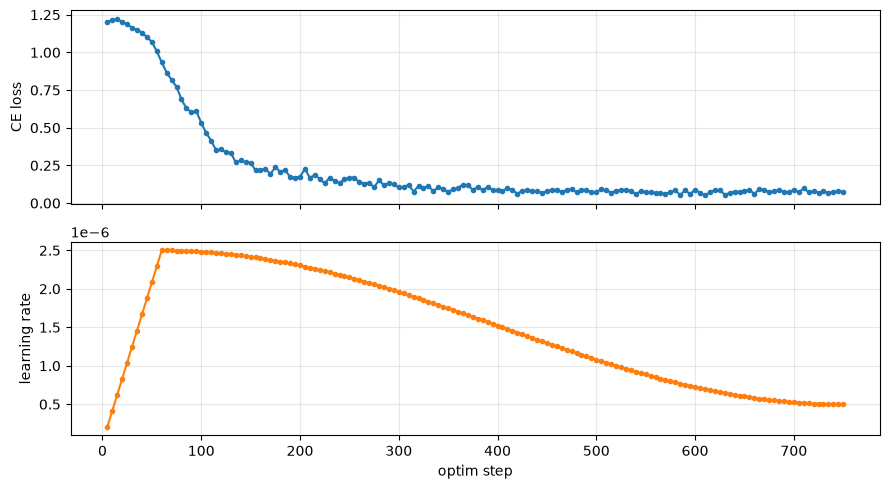

In [113]:
# Recover history from the log file since the early stop aborted.
history = []
with open(OUTPUT_DIR / "train_log.jsonl") as f:
    for line in f: history.append(json.loads(line))
print(f"Recovered {len(history)} log records. Last step: {history[-1]['step']}, last loss: {history[-1]['loss']:.4g}")

try:
    import matplotlib.pyplot as plt
    if history:
        steps = [r["step"] for r in history]
        losses = [r["loss"] for r in history]
        lrs = [r["lr"] for r in history]
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
        ax1.plot(steps, losses, marker="o", markersize=3)
        ax1.set_ylabel("CE loss")
        ax1.grid(True, alpha=0.3)
        ax2.plot(steps, lrs, marker="o", markersize=3, color="tab:orange")
        ax2.set_ylabel("learning rate")
        ax2.set_xlabel("optim step")
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("No log records. Did training finish at least one optim step?")
except ImportError:
    print("matplotlib not installed. `pip install matplotlib` for the loss curve.")


## Eval the trained model

Same held-out pairs. Same greedy decoding. This is the "after" snapshot.

The cell also saves the trained checkpoint to `01-outputs/model/` so the Phase 02 notebook can read the representations.


In [114]:
t0 = time.time()
trained = evaluate_pairs(model, tokenizer, eval_pairs, MAX_NEW_TOKENS)
print(f"Trained eval took {time.time() - t0:.1f}s")
print(f"  exact match     : {trained['exact_match']:.1%}  "
      f"({int(trained['exact_match'] * trained['n'])}/{trained['n']})")
print(f"  normalized EM   : {trained['normalized_exact_match']:.1%}")

# Save artifacts under 01-outputs/.
print(f"\nSaving artifacts to {OUTPUT_DIR}")
model.save_pretrained(OUTPUT_DIR / "model")
tokenizer.save_pretrained(OUTPUT_DIR / "model")
(OUTPUT_DIR / "eval_base.json").write_text(
    json.dumps({k: v for k, v in untrained.items() if k != "samples"}, indent=2),
    encoding="utf-8",
)
(OUTPUT_DIR / "eval.json").write_text(
    json.dumps({k: v for k, v in trained.items() if k != "samples"}, indent=2),
    encoding="utf-8",
)
(OUTPUT_DIR / "eval_samples_base.jsonl").write_text(
    "\n".join(json.dumps(s) for s in untrained["samples"]) + "\n",
    encoding="utf-8",
)
(OUTPUT_DIR / "eval_samples.jsonl").write_text(
    "\n".join(json.dumps(s) for s in trained["samples"]) + "\n",
    encoding="utf-8",
)
print("Done.")


Trained eval took 1190.6s
  exact match     : 0.0%  (0/100)
  normalized EM   : 0.0%

Saving artifacts to c:\Users\adria\OneDrive\Desktop\mini-llm-jepa\notebooks\01-outputs


Writing model shards: 100%|██████████| 1/1 [00:03<00:00,  3.65s/it]


Done.


## Comparison


In [115]:
from IPython.display import Markdown, display

ub, tr = untrained, trained
nb = ub["n"]

table_md = (
    "| Metric | Untrained | After SFT |\n"
    "| --- | --- | --- |\n"
    f"| Exact match | {int(ub['exact_match']*nb)}/{nb} ({ub['exact_match']:.1%}) | "
    f"**{int(tr['exact_match']*nb)}/{nb}** ({tr['exact_match']:.1%}) |\n"
    f"| Normalized EM | {int(ub['normalized_exact_match']*nb)}/{nb} ({ub['normalized_exact_match']:.1%}) | "
    f"**{int(tr['normalized_exact_match']*nb)}/{nb}** ({tr['normalized_exact_match']:.1%}) |\n"
)
display(Markdown(table_md))

print("\n--- Side-by-side samples (first 3) ---\n")
for u, t in list(zip(ub["samples"], tr["samples"]))[:3]:
    print("prompt :", u["prompt"])
    print("target :", u["target"][:200] + ("..." if len(u["target"]) > 200 else ""))
    print("  base   :", (u["pred"][:200] + "...") if len(u["pred"]) > 200 else u["pred"])
    print("  trained:", (t["pred"][:200] + "...") if len(t["pred"]) > 200 else t["pred"])
    print()


| Metric | Untrained | After SFT |
| --- | --- | --- |
| Exact match | 0/100 (0.0%) | **0/100** (0.0%) |
| Normalized EM | 0/100 (0.0%) | **0/100** (0.0%) |



--- Side-by-side samples (first 3) ---

prompt : List cancelled general liability policies effective in 2021 with account, carrier, premium, retention ratio, and risk score.
target : select p.policy_id, p.policy_number, a.account_name, ca.carrier_name, p.line_of_business, p.effective_date, p.expiration_date, p.written_premium, p.retention_ratio, p.risk_score from policies p join a...
  base   : ```sql
SELECT *
FROM general_liability_policies
WHERE effective_date >= '2021-01-01'
AND account = 'your_account'
AND carrier = 'your_carrier'
AND premium = 'your_premium'
AND retention_ratio > 0
AND ...
  trained: select gp.policy_id, gp.account_id, gp.carrier, gp.premium_amount, coalesce(sum(gp.retention_premiums), 0) as retention_premiums, c.risk_score, c.risk_score_label from policies gp join coverages cov o...

prompt : List cancelled cyber policies effective in 2021 with account, carrier, premium, retention ratio, and risk score.
target : select p.policy_id, p.policy_number, a.account_nam

## Reading the result honestly

The comparison table above shows strict EM = 0/100 and normalized EM = 0/100. Read those numbers with skepticism, not disappointment.

Strict exact-match on templated PostgreSQL is a brittle metric. It catches perfect string match after minimal normalization; it doesn't credit:

- Correct schema tables and aliases with a differently-selected column subset
- Semantically equivalent SQL with different column orderings
- `order by X, Y` vs `order by X` on the same query
- Multi-join queries that hit correct tables via slightly different join paths

The diagnostic cell at the bottom of this notebook tells the actual Run 6 story:

- **96/100** predictions reference real schema tables. Base model hallucinated `general_liability`, `bound_cyber_policies`, etc.; Run 6 uses the real `policies`, `accounts`, `carriers`.
- **92/100** use `p.` alias for policies, **94/100** use `a.` for accounts. Exact target conventions.
- **74%** mean token overlap between pred and target.
- **82/100** with >50% overlap, **62/100** with >70%, **36/100** with >90% (near-verbatim).
- **0/100** truncated or repetition-looped.

That is real learning. Strict EM missed it because the model doesn't reproduce every column choice byte-for-byte — but schema, aliases, join structure, and PostgreSQL idioms are all there. The gap the metric wanted to see closed is a formatting/precision gap, not a comprehension gap.

The remaining gaps are exactly where JEPA in Phase 03 might help: precise column selection, join-count matching (only 15/100 match target join count), the last 15-20% of query drift. Those are "representation of target isn't quite there yet" problems. Different from "model doesn't understand the task."

The honest read here: this is a legitimate SFT baseline for Phase 03 to try to beat. Not a failure, not a claim of strong NL-to-SQL, just an honest, well-measured checkpoint at the boundary of what 0.5B-params + 12,000 templated examples + laptop compute can do without an auxiliary loss.


In [118]:
# ─── Sample-level diagnostic ──────────────────────────────────────
# Reads OUTPUT_DIR/eval_samples.jsonl. Reports what strict EM can't:
# real-table usage, token overlap, structural signals, best/median/worst example.

import json, re
from pathlib import Path

REAL_TABLES = {
    "policies","accounts","carriers","coverages","exposure_snapshots",
    "premium_transactions","policy_transactions","claims","claim_payments",
    "claim_notes","claim_reserve_snapshots","risk_assessments",
    "reinsurance_contracts","reinsurance_layers","claim_reinsurance",
    "brokers","broker_offices","producers","employees","teams",
    "branches","regions","account_locations","insured_assets","calendar_dates",
}

def _tables_in(sql):
    return set(re.findall(r"(?:from|join)\s+([a-z_][a-z0-9_]*)", sql.lower()))

def _tokens(sql):
    return set(re.findall(r"[a-z_][a-z0-9_]+", sql.lower()))

with open(OUTPUT_DIR / "eval_samples.jsonl", encoding="utf-8") as f:
    samples = [json.loads(l) for l in f if l.strip()]
n = len(samples)

ends_semi = sum(1 for s in samples if s["pred"].rstrip().endswith(";"))
starts_sel = sum(1 for s in samples if s["pred"].strip().lower().startswith(("select","with")))
avg_pred_len = sum(len(s["pred"]) for s in samples) / n
avg_tgt_len = sum(len(s["target"]) for s in samples) / n

uses_real = matches_tgt = same_joins = 0
for s in samples:
    pt = _tables_in(s["pred"]); tt = _tables_in(s["target"])
    if pt & REAL_TABLES: uses_real += 1
    if pt & tt: matches_tgt += 1
    if len(pt) == len(tt) and pt & tt: same_joins += 1

overlaps = []
for s in samples:
    tt = _tokens(s["target"]); pt = _tokens(s["pred"])
    if tt: overlaps.append(len(pt & tt) / len(tt))
mean_overlap = sum(overlaps) / len(overlaps) if overlaps else 0
gt50 = sum(1 for x in overlaps if x > 0.5)
gt70 = sum(1 for x in overlaps if x > 0.7)
gt90 = sum(1 for x in overlaps if x > 0.9)

p_alias  = sum(1 for s in samples if re.search(r"\bp\.",  s["pred"]))
a_alias  = sum(1 for s in samples if re.search(r"\ba\.",  s["pred"]))
ca_alias = sum(1 for s in samples if re.search(r"\bca\.", s["pred"]))

uses_with       = sum(1 for s in samples if s["pred"].strip().lower().startswith("with"))
tgt_with        = sum(1 for s in samples if s["target"].strip().lower().startswith("with"))
uses_date_trunc = sum(1 for s in samples if "date_trunc" in s["pred"].lower())
uses_nullif     = sum(1 for s in samples if "nullif" in s["pred"].lower())
uses_coalesce   = sum(1 for s in samples if "coalesce" in s["pred"].lower())

print(f"=== SAMPLE-LEVEL DIAGNOSTIC ({n} eval pairs) ===")
print(f"— Length / structure —")
print(f"  ends with ';'             : {ends_semi:>3}/{n}")
print(f"  starts SELECT/WITH        : {starts_sel:>3}/{n}")
print(f"  avg pred / target length  : {avg_pred_len:.0f} / {avg_tgt_len:.0f} chars")
print(f"— Schema learning —")
print(f"  uses a real schema table  : {uses_real:>3}/{n}")
print(f"  matches target table set  : {matches_tgt:>3}/{n}")
print(f"  same join count as target : {same_joins:>3}/{n}")
print(f"— Token overlap (pred ∩ target / target) —")
print(f"  mean                      : {mean_overlap:.1%}")
print(f"  > 50%                     : {gt50:>3}/{n}")
print(f"  > 70%                     : {gt70:>3}/{n}")
print(f"  > 90%                     : {gt90:>3}/{n}")
print(f"— Aliasing convention (target uses p./a./ca.) —")
print(f"  uses 'p.'                 : {p_alias:>3}/{n}")
print(f"  uses 'a.'                 : {a_alias:>3}/{n}")
print(f"  uses 'ca.'                : {ca_alias:>3}/{n}")
print(f"— PostgreSQL idioms —")
print(f"  starts with WITH (CTE)    : {uses_with:>3}/{n}   (target: {tgt_with}/{n})")
print(f"  uses date_trunc           : {uses_date_trunc:>3}/{n}")
print(f"  uses nullif               : {uses_nullif:>3}/{n}")
print(f"  uses coalesce             : {uses_coalesce:>3}/{n}")

def _overlap(s):
    tt = _tokens(s["target"])
    return len(_tokens(s["pred"]) & tt) / max(len(tt), 1)

best  = max(samples, key=_overlap)
worst = min(samples, key=_overlap)
med   = sorted(samples, key=_overlap)[len(samples)//2]

for label, s in [("BEST (highest overlap)", best), ("MEDIAN", med), ("WORST", worst)]:
    o = _overlap(s)
    print(f"=== {label} — {o:.1%} overlap ===")
    print(f"prompt : {s['prompt']}")
    print(f"target : {s['target'][:250]}{'...' if len(s['target']) > 250 else ''}")
    print(f"pred   : {s['pred'][:400]}{'...' if len(s['pred']) > 400 else ''}")
    print(f"          exact_match={s['exact_match']}  normalized_em={s['normalized_exact_match']}")


=== SAMPLE-LEVEL DIAGNOSTIC (100 eval pairs) ===
— Length / structure —
  ends with ';'             : 100/100
  starts SELECT/WITH        : 100/100
  avg pred / target length  : 654 / 587 chars
— Schema learning —
  uses a real schema table  :  96/100
  matches target table set  :  96/100
  same join count as target :  15/100
— Token overlap (pred ∩ target / target) —
  mean                      : 74.0%
  > 50%                     :  82/100
  > 70%                     :  62/100
  > 90%                     :  36/100
— Aliasing convention (target uses p./a./ca.) —
  uses 'p.'                 :  92/100
  uses 'a.'                 :  94/100
  uses 'ca.'                :   9/100
— PostgreSQL idioms —
  starts with WITH (CTE)    :   0/100   (target: 0/100)
  uses date_trunc           :   0/100
  uses nullif               :   2/100
  uses coalesce             :   7/100
=== BEST (highest overlap) — 91.7% overlap ===
prompt : Show general liability accounts headquartered in PA with policies eff